<a href="https://colab.research.google.com/github/RamitSachdev/IML_Assignment1/blob/main/IML_A1_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

# Loading the diabetes dataset and then splitting for train and test
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# we will have to standardise as kernel regression is sensitive (got to know this from gpt and hence edited code and variables a bit)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 353, Test samples: 89


In [3]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train_preds = lr.predict(X_train)
lr_test_preds  = lr.predict(X_test)

lr_train_mse = mse(y_train, lr_train_preds)
lr_test_mse  = mse(y_test,  lr_test_preds)

print("=== Linear Regression (OLS) ===")
print(f"Train MSE: {lr_train_mse:.2f}")
print(f"Test  MSE: {lr_test_mse:.2f}")

=== Linear Regression (OLS) ===
Train MSE: 2749.28
Test  MSE: 3368.04


In [4]:
# Kernel 1: RBF (Gaussian) kernel
krr_rbf = KernelRidge(kernel="rbf", alpha=1.0, gamma=0.1)
krr_rbf.fit(X_train_scaled, y_train)

rbf_train_preds = krr_rbf.predict(X_train_scaled)
rbf_test_preds  = krr_rbf.predict(X_test_scaled)

rbf_train_mse = mse(y_train, rbf_train_preds)
rbf_test_mse  = mse(y_test,  rbf_test_preds)

print("=== Kernel Ridge Regression: RBF Kernel ===")
print(f"K(x, z) = exp(-gamma * ||x - z||^2),  gamma=0.1, alpha=1.0")
print(f"Train MSE: {rbf_train_mse:.2f}")
print(f"Test  MSE: {rbf_test_mse:.2f}")

# Kernel 2: Polynomial kernel
krr_poly = KernelRidge(kernel="polynomial", alpha=1.0, degree=3, coef0=1)
krr_poly.fit(X_train_scaled, y_train)

poly_train_preds = krr_poly.predict(X_train_scaled)
poly_test_preds  = krr_poly.predict(X_test_scaled)

poly_train_mse = mse(y_train, poly_train_preds)
poly_test_mse  = mse(y_test,  poly_test_preds)

print("\n=== Kernel Ridge Regression: Polynomial Kernel ===")
print(f"K(x, z) = (x^T z + 1)^3,  degree=3, coef0=1, alpha=1.0")
print(f"Train MSE: {poly_train_mse:.2f}")
print(f"Test  MSE: {poly_test_mse:.2f}")

#help from got was taken for this cell of code and to understand both RBF and Polynomial in coding

=== Kernel Ridge Regression: RBF Kernel ===
K(x, z) = exp(-gamma * ||x - z||^2),  gamma=0.1, alpha=1.0
Train MSE: 2275.69
Test  MSE: 3685.10

=== Kernel Ridge Regression: Polynomial Kernel ===
K(x, z) = (x^T z + 1)^3,  degree=3, coef0=1, alpha=1.0
Train MSE: 1927.29
Test  MSE: 3609.94


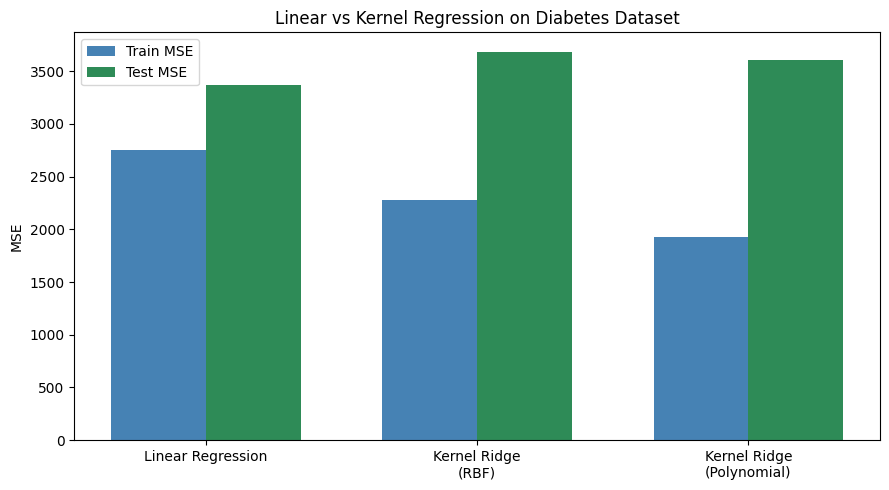

Summary
Model                                  Train MSE     Test MSE
------------------------------------------------------------
Linear Regression (OLS)                  2749.28      3368.04
Kernel Ridge (RBF)                       2275.69      3685.10
Kernel Ridge (Polynomial deg=3)          1927.29      3609.94


In [5]:
models      = ["Linear Regression", "Kernel Ridge\n(RBF)", "Kernel Ridge\n(Polynomial)"]
train_mses  = [lr_train_mse, rbf_train_mse, poly_train_mse]
test_mses   = [lr_test_mse,  rbf_test_mse,  poly_test_mse]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, train_mses, width, label="Train MSE", color="steelblue")
ax.bar(x + width/2, test_mses,  width, label="Test MSE",  color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("MSE")
ax.set_title("Linear vs Kernel Regression on Diabetes Dataset")
ax.legend()
plt.tight_layout()
plt.show()

print("Summary")
print(f"{'Model':<35} {'Train MSE':>12} {'Test MSE':>12}")
print("-" * 60)
print(f"{'Linear Regression (OLS)':<35} {lr_train_mse:>12.2f} {lr_test_mse:>12.2f}")
print(f"{'Kernel Ridge (RBF)':<35} {rbf_train_mse:>12.2f} {rbf_test_mse:>12.2f}")
print(f"{'Kernel Ridge (Polynomial deg=3)':<35} {poly_train_mse:>12.2f} {poly_test_mse:>12.2f}")

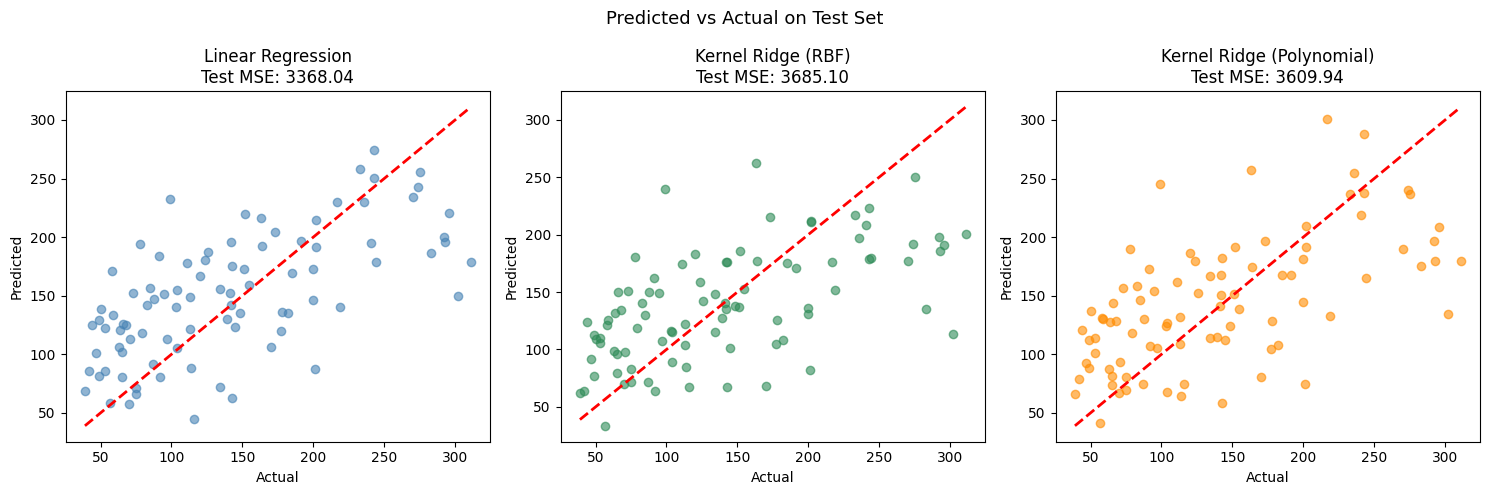

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    (lr_test_preds,   "Linear Regression",         lr_test_mse,   "steelblue"),
    (rbf_test_preds,  "Kernel Ridge (RBF)",         rbf_test_mse,  "seagreen"),
    (poly_test_preds, "Kernel Ridge (Polynomial)",  poly_test_mse, "darkorange"),
]

for ax, (preds, title, test_mse, color) in zip(axes, pairs):
    ax.scatter(y_test, preds, alpha=0.6, color=color)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{title}\nTest MSE: {test_mse:.2f}")

plt.suptitle("Predicted vs Actual on Test Set", fontsize=13)
plt.tight_layout()
plt.show()

#help from claude taken